# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** GDPR Fines, European Revenue Share, and Advertising Dependence at Meta and Alphabet (2016-2025)
- **Student Name:** Daria Chelyukanova
- **Policy Relevance Statement:** GDPR enforcement may affect technology firms beyond the direct cost of fines. By examining Meta and Alphabet, this project studies whether data protection regulation is associated with changes in firms’ European revenue share and their dependence on advertising revenue.
- **Central Hypothesis:** After the introduction of the GDPR in 2018, Meta and Alphabet’s Europe revenue share will decline or grow more slowly relative to other regions. I also expect larger GDPR fines to be associated with lower Europe revenue share and lower advertising revenue share, suggesting that regulatory pressure may affect both regional performance and advertising dependence. (The DSA period after 2022 is considered as additional policy context, but the main focus of the analysis is GDPR enforcement.)

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** Meta and Alphabet 10-K reports (HTML format) years 2014-2025, analysed and turned into CSV file by an AI agent
- **Secondary Data Source:** GDPR Enforcement Tracker (CMS) https://www.enforcementtracker.com
- **Variables Retrieved:** All
- **Local Storage Path:** `data/final_project/daria-chelyukanova/company_revenue_raw.csv` & `data/final_project/daria-chelyukanova/gdpr_fines_raw.csv`



In [3]:
import sys
from pathlib import Path

example_dir = Path(".").resolve()
if str(example_dir) not in sys.path:
    sys.path.insert(0, str(example_dir))

import data

df_revenue_raw, df_gdpr_raw = data.run()
df_revenue_raw.head()

,Company,Year,Total_Revenue,Advertising_Revenue,Non_Advertising_Revenue,Regional_Revenue_US,Regional_Revenue_Europe,Regional_Revenue_Asia,Regional_Revenue_RoW
0,Meta,2014,12466,11492,974,NaN,NaN,NaN,NaN
1,Meta,2015,17928,17079,849,NaN,NaN,NaN,NaN
2,Meta,2016,27638,26885,753,13432.0,6792.0,5037.0,2377.0
3,Meta,2017,40653,39942,711,19065.0,10126.0,7921.0,3541.0
4,Meta,2018,55838,55013,825,25727.0,13631.0,11733.0,4747.0


In [4]:
df_gdpr_raw.head()

,e,c,C,F,a,d,y,f,p,s,r,t,u
0,1,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-12-09,2018.0,4800.0,Betting place,Industry and Commerce,Art. 13 GDPR,Insufficient fulfilment of information obligat...,https://www.dsb.gv.at/documents/22758/116802/S...
1,2,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018,2018.0,1800.0,Kebab restaurant,Accomodation and Hospitality,"Art. 5 GDPR, Art. 13 GDPR, Art. 14 GDPR",Insufficient legal basis for data processing,https://www.dsb.gv.at/documents/22758/115212/N...
2,3,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-09-27,2018.0,300.0,Private car owner,Individuals and Private Associations,"Art. 5 (1) a) GDPR, Art. 6 GDPR",Insufficient legal basis for data processing,https://www.ris.bka.gv.at/Dokumente/Dsk/DSBT_2...
3,4,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-12-20,2018.0,2200.0,Private person,Individuals and Private Associations,"Art. 5 (1) a) GDPR, Art. 5 (1) c) GDPR, Art. 6...",Insufficient legal basis for data processing,https://www.ris.bka.gv.at/Dokumente/Dsk/DSBT_2...
4,5,BELGIUM,Belgium,/flags/flag_belgium.png,Belgian Data Protection Authority (APD),2019-05-28,2019.0,2000.0,Mayor,Public Sector and Education,"Art. 5 (1) b) GDPR, Art. 6 GDPR",Insufficient legal basis for data processing,https://www.autoriteprotectiondonnees.be/news/...


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Merging Strategy:** Company-year left merge to pair annual GDPR fines issued against Meta and Alphabet with each company's revenue breakdown by region and product.
- **Pre-cleaned Observations:** GDPR dataset: 3,195 rows and 13 columns. Revenue dataset: 24 rows and 9 columns.
- **Final Dataset Observations:** 24 clean rows and 13 columns (years 2014-2025 (repeated twice for each company - Meta and Alphabet) dropped non Meta/Alphabet companies and aggregated fines for each year).
- **Clean Data Path:** `data/final_project/daria-chelyukanova/merged_revenue_gdpr.csv`



In [51]:
import importlib
import manipulate

importlib.reload(manipulate)

df_revenue_clean = manipulate.revenue_clean(df_revenue_raw)
df_gdpr_clean = manipulate.gdpr_clean(df_gdpr_raw)

df_gdpr_summary = manipulate.summarise_gdpr(df_gdpr_clean)

df_merged = manipulate.merged_revenue_gdpr(
    df_revenue_clean,
    df_gdpr_summary
)

df_merged.to_csv(
    "../../../data/final_project/daria-chelyukanova/merged_revenue_gdpr.csv",
    index=False
)

df_merged.head()

,company,year,total_revenue,advertising_revenue,non_advertising_revenue,regional_revenue_us,regional_revenue_europe,regional_revenue_asia,regional_revenue_row,us_revenue_share,europe_revenue_share,asia_revenue_share,row_revenue_share,advertising_revenue_share,non_advertising_revenue_share,total_fine_amount,number_of_fines
0,Meta,2016,27638,26885,753,13432.0,6792.0,5037.0,2377.0,48.599754,24.574861,18.224908,8.600478,97.275490,2.724510,0.0,0.0
1,Meta,2017,40653,39942,711,19065.0,10126.0,7921.0,3541.0,46.896908,24.908371,19.484417,8.710304,98.251052,1.748948,0.0,0.0
2,Meta,2018,55838,55013,825,25727.0,13631.0,11733.0,4747.0,46.074358,24.411691,21.012572,8.501379,98.522512,1.477488,0.0,0.0
3,Meta,2019,70697,69655,1042,32206.0,16826.0,15406.0,6259.0,45.554974,23.800161,21.791589,8.853275,98.526104,1.473896,51000.0,1.0
4,Meta,2020,85965,84169,1796,38433.0,20349.0,19848.0,7335.0,44.707730,23.671262,23.088466,8.532542,97.910778,2.089222,0.0,0.0


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure 1 Key Takeaway (Regional Revenue Share vs GDPR Fines):** *Meta:* Shows a slight decline in Europe's revenue after the adoption of the GDPR, as well as during the adoption of DSA. It doesn't seem to be impacted by the fines. *Alphabet:* Shows a sliht decline in Europe's revenue after the introduction of the GDPR in 2018, dips slightly in 2022 (during the introduction of the DSA) and is continuously declining. There is a pattern of a decline in revenue the year after a medium/big fine.
- **Figure 2 Key Takeaway (Global Advertising Revenue Share vs GDPR Fines):** *Meta:* The global advertising revenue takes a dip after 2019, shortly recovering in 2023 before declining again. Impact of the GDPR fine can be observed on the decline in revenue. *Alphabet:* Generally showcases a pattern of an overall decline from 2016. Revenue declines further after a fine.



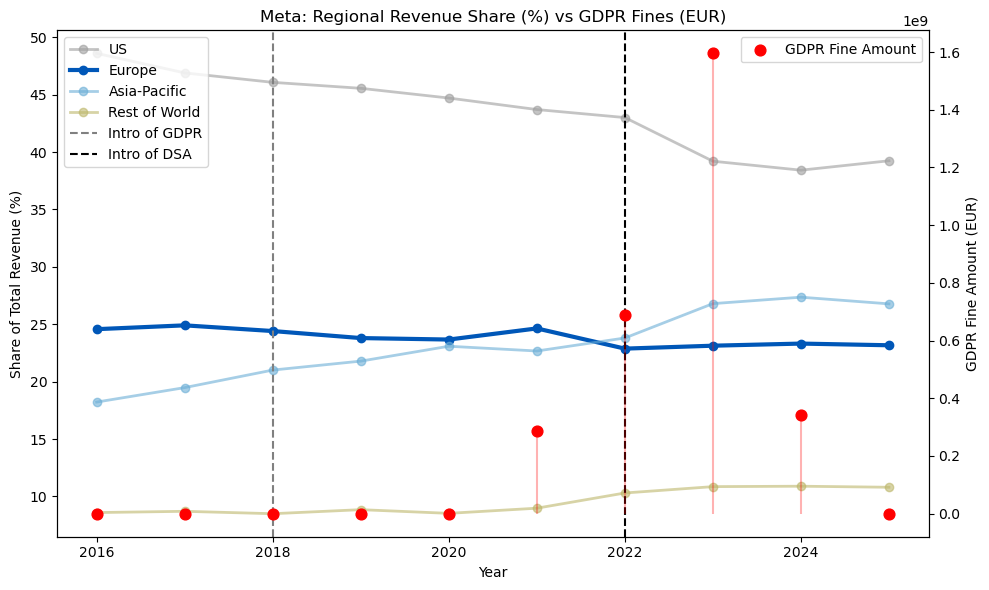

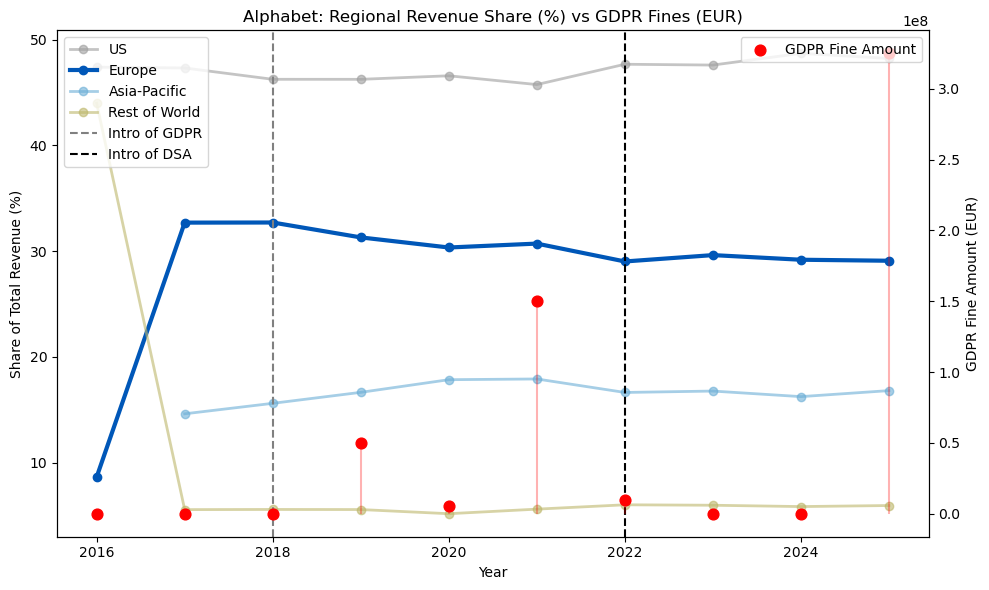

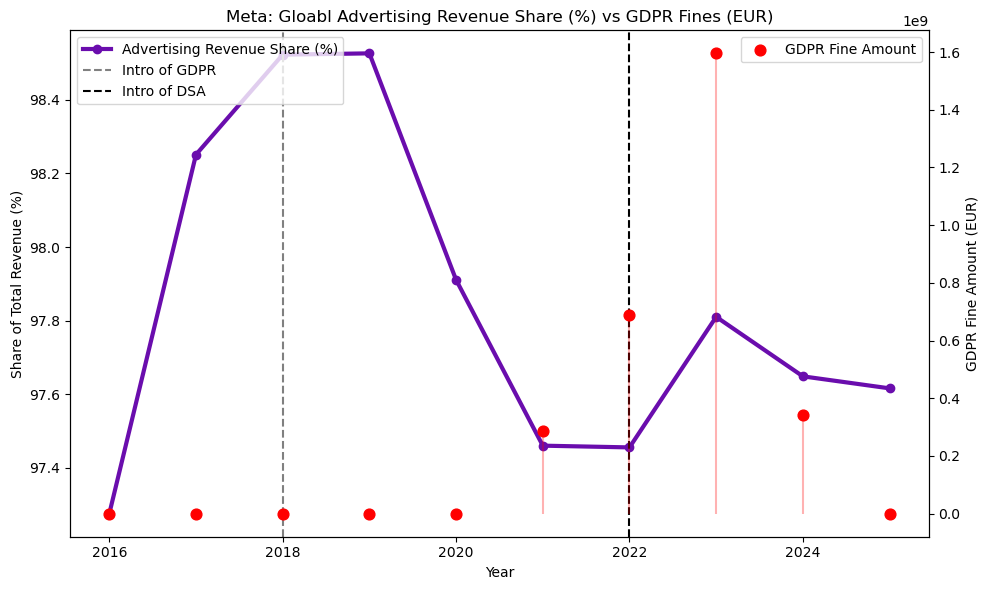

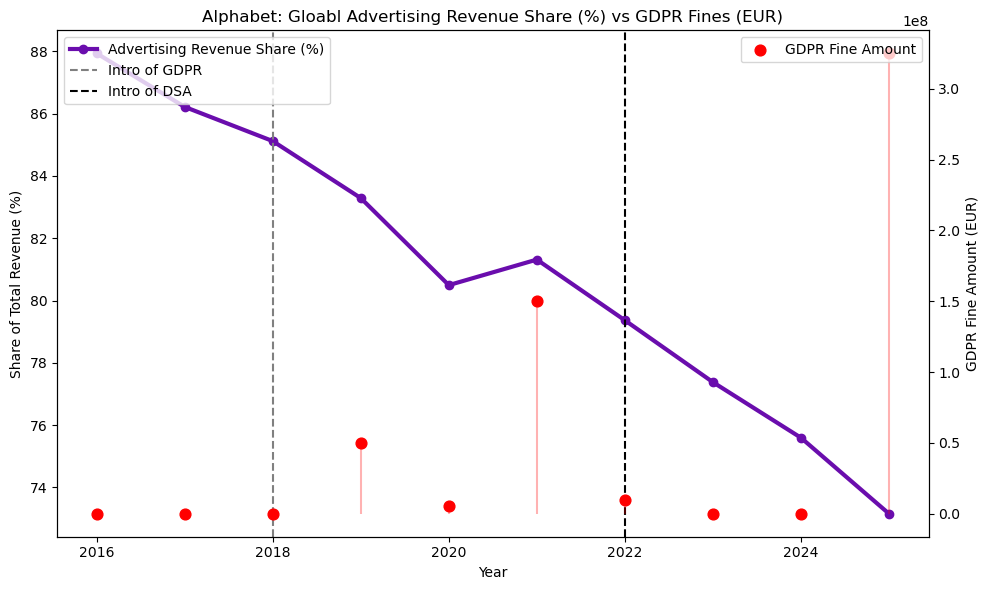

In [53]:
import importlib
import graph

importlib.reload(graph)

df_graph = graph.run()


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** OLS regression (*Model 1:* Europe revenue share; *Model 2:* Advertising revenue share)
- **Model Fit Metrics:** *Model 1:* R-squared = 0.297, Number of Observations = 20; *Model 2:* R-squared = 0.901, Number of Observations = 20
- **Coefficient of Primary Variable:** *Model 1:* post_gdpr: Coefficient: 4.5990, Std. Err: 2.843, T-stat: 1.618 (p-value: 0.125); fine_amount_mil: Coefficient: -0.0017, Std. Err: 0.003, T-stat: -0.522 (p-value: 0.609) ; *Model 2:* post_gdpr: Coefficient: -3.7248, Std. Err: 1.830, T-stat: -2.035 (p-value: 0.059); fine_amount_mil: Coefficient: -0.0001, Std. Err: 0.002, T-stat: -0.066 (p-value: 0.949)
- **Statistical Significance:** *Model 1:* Post-GDPR and the fine amount variables are not statistically signifacnt at the 0.05 level. *Model 2:* Post-GDPR coefficient is close to signifance but doesn't cross the 0.05 threshold.
- **Key Conclusion:** The models do not show strong evidence that GDPR fines are directly associated with a decline Europe's regional revenue share (both Meta and Alphabet), same with advertising revenue share. However, Model 2 suggests a possible post-GDPR decline in advertising revenue. 
- **Limitations:** The dataset is very small (only 20 observations for only 2 companies), so I cannot say that this data should be interpreted as causal evidence, rather I see it as a descriptive one.



In [44]:
# sorry, I've never done this before, so it may not be fully right!

import importlib
import model

importlib.reload(model)

europe_model, advertising_model = model.run()


Model 1: Europe Revenue Share
                             OLS Regression Results                             
Dep. Variable:     europe_revenue_share   R-squared:                       0.297
Model:                              OLS   Adj. R-squared:                  0.165
Method:                   Least Squares   F-statistic:                     2.249
Date:                  Mon, 13 Jul 2026   Prob (F-statistic):              0.122
Time:                          18:04:05   Log-Likelihood:                -58.056
No. Observations:                    20   AIC:                             124.1
Df Residuals:                        16   BIC:                             128.1
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [45]:
europe_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     europe_revenue_share   R-squared:                       0.297
Model:                              OLS   Adj. R-squared:                  0.165
Method:                   Least Squares   F-statistic:                     2.249
Date:                  Mon, 13 Jul 2026   Prob (F-statistic):              0.122
Time:                          18:05:33   Log-Likelihood:                -58.056
No. Observations:                    20   AIC:                             124.1
Df Residuals:                        16   BIC:                             128.1
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             24.7353      2.728      9.069      0.000      18.953      30.518
C(company)[T.Meta]    -4.0721      2.334     -1.744      0.100      -9.021       0.877
post_gdpr              4.5990      2.843      1.618      0.125      -1.428      10.626
fine_amount_mil       -0.0017      0.003     -0.522      0.609      -0.009       0.005
==============================================================================
Omnibus:                       26.017   Durbin-Watson:                   2.163
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.502
Skew:                          -2.047   Prob(JB):                     1.78e-11
Kurtosis:                       9.531   Cond. No.                     1.42e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.42e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [46]:
advertising_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     advertising_revenue_share   R-squared:                       0.901
Model:                                   OLS   Adj. R-squared:                  0.882
Method:                        Least Squares   F-statistic:                     48.53
Date:                       Mon, 13 Jul 2026   Prob (F-statistic):           2.95e-08
Time:                               18:05:41   Log-Likelihood:                -49.247
No. Observations:                         20   AIC:                             106.5
Df Residuals:                             16   BIC:                             110.5
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             83.9738      1.756     47.825      0.000      80.252      87.696
C(company)[T.Meta]    16.8934      1.503     11.242      0.000      13.708      20.079
post_gdpr             -3.7248      1.830     -2.035      0.059      -7.605       0.155
fine_amount_mil       -0.0001      0.002     -0.066      0.949      -0.005       0.004
==============================================================================
Omnibus:                        2.880   Durbin-Watson:                   0.425
Prob(Omnibus):                  0.237   Jarque-Bera (JB):                1.606
Skew:                          -0.687   Prob(JB):                        0.448
Kurtosis:                       3.198   Cond. No.                     1.42e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.42e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""